In [ ]:
from mido import MidiFile, tempo2bpm
import networkx as nx
import os
import glob
import multiprocessing
import sqlite3
import json
import os
import glob
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.metrics import precision_recall_curve, auc
import random
import warnings
from itertools import combinations
from concurrent.futures import ThreadPoolExecutor, as_completed
import random
from datetime import datetime


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DB_PATH = '/content/drive/MyDrive/midi_project.db'



CONTOUR_MAP = {'Start': 0, 'Up': 1, 'Repeat': 0, 'Down': -1}

def encode_vector(features: list) -> np.ndarray:
    if not features:
        return np.zeros(12)
    intervals, contours, weights = [], [], []
    for f in features:
        iv = f['interval']
        intervals.append(float(iv) if isinstance(iv, (int, float)) else 0.0)
        contours.append(float(CONTOUR_MAP.get(f['contour'], 0)))
        weights.append(float(f['weight']))
    def stats(arr):
        a = np.array(arr)
        return [a.mean(), a.std(), a.min(), a.max()]
    return np.array(stats(intervals) + stats(contours) + stats(weights))

def build_vector_matrix(songs: list) -> np.ndarray:
    return np.array([encode_vector(s['features']) for s in songs])

def all_vector_similarities(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    norms[norms == 0] = 1
    normed = matrix / norms
    return normed @ normed.T

def vector_similarity(features_a: list, features_b: list) -> float:
    va, vb = encode_vector(features_a), encode_vector(features_b)
    na, nb = np.linalg.norm(va), np.linalg.norm(vb)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(va, vb) / (na * nb))


def edge_fingerprint(edge: dict) -> tuple:
    interval = edge['interval']
    if interval == 0:
        bucket = 0
    elif 1 <= abs(interval) <= 2:
        bucket = 1 * (1 if interval > 0 else -1)
    elif 3 <= abs(interval) <= 5:
        bucket = 3 * (1 if interval > 0 else -1)
    elif 6 <= abs(interval) <= 8:
        bucket = 6 * (1 if interval > 0 else -1)
    elif 9 <= abs(interval) <= 12:
        bucket = 9 * (1 if interval > 0 else -1)
    else:
        bucket = 13 * (1 if interval > 0 else -1)
    return (edge['type'], edge['contour'], bucket)

def fingerprint_bag(edges: list) -> dict:
    bag = {}
    for e in edges:
        key = edge_fingerprint(e)
        bag[key] = bag.get(key, 0) + 1
    return bag

def graph_similarity_bags(bag_a: dict, bag_b: dict) -> float:
    all_keys = set(bag_a) | set(bag_b)
    intersection = sum(min(bag_a.get(k, 0), bag_b.get(k, 0)) for k in all_keys)
    union        = sum(max(bag_a.get(k, 0), bag_b.get(k, 0)) for k in all_keys)
    return 0.0 if union == 0 else float(intersection / union)

def graph_similarity(nodes_a, edges_a, nodes_b, edges_b) -> float:
    return graph_similarity_bags(fingerprint_bag(edges_a), fingerprint_bag(edges_b))


def load_all_songs(db_path=DB_PATH):
    conn = sqlite3.connect(db_path, timeout=30)
    try:
        c = conn.cursor()
        c.execute('''
            SELECT s.id, s.artist, s.title, vf.features, gd.nodes, gd.edges
            FROM songs s
            JOIN vector_features vf ON vf.song_id = s.id
            JOIN graph_data      gd ON gd.song_id = s.id
        ''')
        rows = c.fetchall()
    finally:
        conn.close()
    return [
        {'id': r[0], 'artist': r[1], 'title': r[2],
         'features': json.loads(r[3]), 'nodes': json.loads(r[4]), 'edges': json.loads(r[5])}
        for r in rows
    ]

def load_song_by_id(song_id: int, db_path=DB_PATH):
    conn = sqlite3.connect(db_path, timeout=30)
    try:
        c = conn.cursor()
        c.execute('''
            SELECT s.id, s.artist, s.title, vf.features, gd.nodes, gd.edges
            FROM songs s
            JOIN vector_features vf ON vf.song_id = s.id
            JOIN graph_data      gd ON gd.song_id = s.id
            WHERE s.id = ?
        ''', (song_id,))
        r = c.fetchone()
    finally:
        conn.close()
    if r is None:
        raise ValueError(f"song id={song_id} not found")
    return {'id': r[0], 'artist': r[1], 'title': r[2],
            'features': json.loads(r[3]), 'nodes': json.loads(r[4]), 'edges': json.loads(r[5])}

def find_song_id(artist: str, title: str, db_path=DB_PATH):
    conn = sqlite3.connect(db_path, timeout=30)
    try:
        c = conn.cursor()
        c.execute('''
            SELECT id FROM songs
            WHERE LOWER(artist) LIKE ? AND LOWER(title) LIKE ?
            LIMIT 1
        ''', (f'%{artist.lower()}%', f'%{title.lower()}%'))
        row = c.fetchone()
    finally:
        conn.close()
    return row[0] if row else None

def ensure_similarities_table(conn):
    conn.cursor().execute('''CREATE TABLE IF NOT EXISTS similarities (
        song_id INTEGER, song2_id INTEGER, vector_sim REAL, graph_sim REAL,
        PRIMARY KEY (song_id, song2_id),
        FOREIGN KEY(song_id) REFERENCES songs(id),
        FOREIGN KEY(song2_id) REFERENCES songs(id)
    )''')
    conn.commit()

def _flush(conn, buffer: list):
    conn.cursor().executemany(
        'INSERT OR REPLACE INTO similarities (song_id, song2_id, vector_sim, graph_sim) VALUES (?, ?, ?, ?)',
        buffer
    )
    conn.commit()

def already_computed_set(conn):
    c = conn.cursor()
    c.execute('SELECT song_id, song2_id FROM similarities')
    return set(c.fetchall())



def query_song_vs_db(song_id: int, db_path=DB_PATH, top_n=20, vector_prefilter=200, workers=8, chunk_size=1000, skip_store=False) -> list:
    query = load_song_by_id(song_id, db_path)
    print(f"[{song_id}] {query['artist']} - {query['title']}")

    print("computing vector similarities in chunks")
    query_vec = encode_vector(query['features'])
    query_vec_norm = query_vec / (np.linalg.norm(query_vec) or 1)

    all_ids, all_artists, all_titles, all_vsims = [], [], [], []
    total_loaded = 0

    conn = sqlite3.connect(db_path, timeout=30)
    try:
        c = conn.cursor()
        c.execute('''
            SELECT s.id, s.artist, s.title, vf.features
            FROM songs s
            JOIN vector_features vf ON vf.song_id = s.id
            WHERE s.id != ?
        ''', (song_id,))
        chunk = c.fetchmany(chunk_size)
        while chunk:
            for row in chunk:
                sid, artist, title, features_json = row
                vec = encode_vector(json.loads(features_json))
                norm = np.linalg.norm(vec)
                vsim = 0.0 if norm == 0 else float(np.dot(query_vec_norm, vec / norm))
                all_ids.append(sid)
                all_artists.append(artist)
                all_titles.append(title)
                all_vsims.append(vsim)
            total_loaded += len(chunk)
            print(f"  vector: {total_loaded:,} songs processed")
            chunk = c.fetchmany(chunk_size)
    finally:
        conn.close()
    print(f"vector done. {total_loaded:,} songs scored.")

    # prefilter to top N by vector
    print(f"step 2/4: prefiltering to top {vector_prefilter} by vector sim...")
    vsims_arr = np.array(all_vsims)
    top_indices = np.argsort(vsims_arr)[::-1][:vector_prefilter]

    filtered_ids     = [all_ids[i] for i in top_indices]
    filtered_artists = [all_artists[i] for i in top_indices]
    filtered_titles  = [all_titles[i] for i in top_indices]
    filtered_vsims   = [all_vsims[i] for i in top_indices]
    print(f"prefilter done. top {vector_prefilter} selected.")

    # load edges only for prefiltered songs, run graph
    print(f"step 3/4: loading graph data for top {vector_prefilter} songs...")
    conn = sqlite3.connect(db_path, timeout=30)
    try:
        c = conn.cursor()
        placeholders = ','.join('?' * len(filtered_ids))
        c.execute(f'SELECT song_id, edges FROM graph_data WHERE song_id IN ({placeholders})', filtered_ids)
        edge_map = {row[0]: json.loads(row[1]) for row in c.fetchall()}
    finally:
        conn.close()
    print("graph data loaded.")

    print(f"step 3/4 (cont): computing graph similarities...")
    query_bag = fingerprint_bag(query['edges'])
    filtered_bags = [fingerprint_bag(edge_map.get(sid, [])) for sid in filtered_ids]

    def compute_gsim(i):
        return i, graph_similarity_bags(query_bag, filtered_bags[i])

    gsims = [0.0] * len(filtered_ids)
    completed = 0
    with ThreadPoolExecutor(max_workers=workers) as executor:
        futures = {executor.submit(compute_gsim, i): i for i in range(len(filtered_ids))}
        for future in as_completed(futures):
            i, gsim = future.result()
            gsims[i] = gsim
            completed += 1
            if completed % 50 == 0:
                print(f"  graph: {completed} / {len(filtered_ids)}")
    print("graph done.")

    # store (optional) and display
    if not skip_store:
        print("step 4/4: storing results...")
        conn = sqlite3.connect(db_path, timeout=30)
        try:
            ensure_similarities_table(conn)
            buffer = [
                (min(song_id, filtered_ids[i]), max(song_id, filtered_ids[i]),
                 filtered_vsims[i], gsims[i])
                for i in range(len(filtered_ids))
            ]
            _flush(conn, buffer)
        finally:
            conn.close()
        print("stored.")
    else:
        print("step 4/4: skipping store.")

    results = sorted(
        zip(filtered_ids, filtered_artists, filtered_titles, filtered_vsims, gsims),
        key=lambda x: x[4], reverse=True
    )

    display = [
        {'id': sid, 'artist': artist, 'title': title,
         'vector_sim': round(vsim, 4), 'graph_sim': round(gsim, 4)}
        for sid, artist, title, vsim, gsim in results[:top_n]
    ]

    return display


def run_sampled_all_vs_all(sample_size=1000, db_path=DB_PATH, batch_size=1000, workers=8, seed=42):
    all_songs = load_all_songs(db_path)
    print(f"{len(all_songs):,} songs in db")

    if sample_size >= len(all_songs):
        sample = all_songs
    else:
        random.seed(seed)
        sample = random.sample(all_songs, sample_size)
        print(f"sampled {sample_size} (seed={seed})")

    n = len(sample)
    total_pairs = n * (n - 1) // 2
    print(f"{total_pairs:,} pairs")

    conn = sqlite3.connect(db_path, timeout=30)
    try:
        ensure_similarities_table(conn)
        done = already_computed_set(conn)
    finally:
        conn.close()

    pairs = [
        (i, j) for i, j in combinations(range(n), 2)
        if (min(sample[i]['id'], sample[j]['id']),
            max(sample[i]['id'], sample[j]['id'])) not in done
    ]
    print(f"{total_pairs - len(pairs):,} already done, {len(pairs):,} remaining")

    print("computing vector similarities...")
    matrix = build_vector_matrix(sample)
    sim_matrix = all_vector_similarities(matrix)

    print("precomputing graph fingerprints...")
    bags = [fingerprint_bag(s['edges']) for s in sample]

    print("computing graph similarities...")

    def compute_gsim_pair(idx_pair):
        i, j = idx_pair
        return i, j, graph_similarity_bags(bags[i], bags[j])

    buffer = []
    pairs_saved = 0

    conn = sqlite3.connect(db_path, timeout=30)
    try:
        with ThreadPoolExecutor(max_workers=workers) as executor:
            futures = {executor.submit(compute_gsim_pair, p): p for p in pairs}
            for future in as_completed(futures):
                i, j, gsim = future.result()
                id_a, id_b = sample[i]['id'], sample[j]['id']
                vsim = float(sim_matrix[i, j])
                s1, s2 = min(id_a, id_b), max(id_a, id_b)
                buffer.append((s1, s2, vsim, gsim))

                if len(buffer) >= batch_size:
                    _flush(conn, buffer)
                    pairs_saved += len(buffer)
                    buffer = []
                    print(f"{pairs_saved:,} / {len(pairs):,}")

        if buffer:
            _flush(conn, buffer)
            pairs_saved += len(buffer)
    finally:
        conn.close()

    print(f"done. {pairs_saved:,} new pairs stored.")


def top_matches(song_id: int, method='graph', top_n=10, db_path=DB_PATH) -> list:
    col = 'vector_sim' if method == 'vector' else 'graph_sim'
    conn = sqlite3.connect(db_path, timeout=30)
    try:
        c = conn.cursor()
        c.execute(f'''
            SELECT
                CASE WHEN song_id = ? THEN song2_id ELSE song_id END AS other_id,
                {col} AS sim, s.artist, s.title
            FROM similarities
            JOIN songs s ON s.id = CASE WHEN song_id = ? THEN song2_id ELSE song_id END
            WHERE song_id = ? OR song2_id = ?
            ORDER BY sim DESC LIMIT ?
        ''', (song_id, song_id, song_id, song_id, top_n))
        rows = c.fetchall()
    finally:
        conn.close()
    return rows

In [ ]:
song_id = find_song_id('"Weird Al" Yankovic', "Amish Paradise")
song_id

7301

In [ ]:
conn = sqlite3.connect(DB_PATH)
c = conn.cursor()
c.execute("SELECT id, artist, title FROM songs where lower(title) like 'amish paradise' LIMIT 20")
for row in c.fetchall():
    print(row)
conn.close()

(7301, '"Weird Al" Yankovic', 'Amish Paradise')


In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/midi_project/results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

test_cases = [
    # weird al parodies
    ("WEIRD_AL", 7301, "Weird Al - Amish Paradise → Coolio - Gangsta's Paradise"),
    ("WEIRD_AL", 7299, "Weird Al - Eat It → Michael Jackson - Beat It"),
    ("WEIRD_AL", 7298, "Weird Al - Headline News → Billy Ray Cyrus - Achy Breaky Heart"),
    ("WEIRD_AL", 7300, "Weird Al - Dare to Be Stupid → Devo style parody"),

    # confirmed samples
    ("SAMPLE", 8651,  "Vanilla Ice - Ice Ice Baby → Queen - Under Pressure"),
    ("SAMPLE", 8455,  "Sugarhill Gang - Rapper's Delight → Chic - Good Times"),
    ("SAMPLE", 8846,  "Puff Daddy - I'll Be Missing You → The Police - Every Breath You Take"),
    ("SAMPLE", 13635, "MC Hammer - Can't Touch This → Ohio Players - Love Rollercoaster &  Prince - When Doves Cry"),
    ("SAMPLE", 7776,  "Tupac - Changes → Chuck Berry - Rock & Roll Music"),
    ("SAMPLE", 7772,  "Tupac - California Love → Donna Summer - I Feel Love"),
    ("SAMPLE", 1966,  "Fugees - Ready Or Not → The Police - Every Breath You Take"),
    ("SAMPLE", 8139,  "Will Smith - Miami → James Brown - Papa's Got a Brand New Bag"),
    ("SAMPLE", 10716, "Tag Team - Whoomp There It Is → James Brown - Sex Machine"),
    ("SAMPLE", 8140,  "Will Smith - Gettin Jiggy Wit It → Stevie Wonder - Isn't She Lovely & Sister Sledge - All American Girls"),

    # interpolations
    ("INTERPOLATION", 15964, "Warren G - Regulate → Michael McDonald - I Keep Forgettin'"),
    ("INTERPOLATION", 3578,  "Blackstreet - No Diggity → Bill Withers - Lean On Me"),

    # lawsuits
    ("LAWSUIT", 2259,  "George Harrison - My Sweet Lord → The Chiffons - He's So Fine"),
    ("LAWSUIT", 14945, "Beach Boys - Surfin USA → Chuck Berry - Sweet Little Sixteen"),
    ("LAWSUIT", 3285,  "Huey Lewis - I Want a New Drug → Ray Parker Jr - Ghostbusters"),
    ("LAWSUIT", 14924, "The Verve - Bittersweet Symphony → Rolling Stones - Sympathy for Devil"),
    ("LAWSUIT", 14430, "Led Zeppelin - Stairway to Heaven → Spirit"),
    ("LAWSUIT", 13395, "Nirvana - Smells Like Teen Spirit → Shocking Blue - Venus"),

    # covers
    ("COVER", 11364, "Shocking Blue - Venus → Frankie Avalon - Venus 1959 original"),
    ("COVER", 14041, "Jimi Hendrix - All Along the Watchtower → Bob Dylan original"),
    ("COVER", 11780, "Jose Feliciano - Light My Fire → The Doors original"),
    ("COVER", 1961,  "Fugees - Killing Me Softly → Roberta Flack original"),
    ("COVER", 10044, "Sting - Roxanne → The Police original"),
    ("COVER", 1804,  "Far Corporation - Stairway to Heaven → Led Zeppelin original"),
    ("COVER", 11367, "Reel Big Fish - Take On Me → a-ha original"),
    ("COVER", 13681, "Mina - Every Breath You Take → The Police original"),
    ("COVER", 15897, "Tina Turner - Proud Mary → CCR original"),
    ("COVER", 5015,  "CCR - I Heard It Through the Grapevine → Marvin Gaye original"),

    # same song variants
    ("VARIANT", 7461,  "Queen - Under Pressure"),
    ("VARIANT", 15974, "The Police - Every Breath You Take"),
    ("VARIANT", 5776,  "Coolio - Gangsta's Paradise"),
    ("VARIANT", 14430, "Led Zeppelin - Stairway to Heaven"),

    # clear negatives
    ("NEGATIVE", 7506,  "Queen - Bohemian Rhapsody → should NOT match Macarena"),
    ("NEGATIVE", 14153, "Los Del Rio - Macarena → should NOT match Smoke on the Water"),
    ("NEGATIVE", 3137,  "Deep Purple - Smoke on the Water → should NOT match Gangsta's Paradise"),
]

results_log = {}
timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = f"{OUTPUT_DIR}/results_{timestamp}.txt"
json_file   = f"{OUTPUT_DIR}/results_{timestamp}.json"

def write(f, line=""):
    print(line)
    f.write(line + "\n")

with open(output_file, "w") as f:
    write(f, "MIDI SIMILARITY TEST RESULTS")
    write(f, f"Run at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    write(f, f"Total test cases: {len(test_cases)}")
    write(f)

    for label, song_id, description in test_cases:
        write(f, "═" * 70)
        write(f, f"[{label}] {description}")
        write(f, "═" * 70)
        try:
            results = query_song_vs_db(song_id, top_n=20, vector_prefilter=200, skip_store=True)
            results_log[(label, song_id, description)] = results

            write(f)
            write(f, f"{'Rank':<5} {'ID':<6} {'Vector':>8} {'Graph':>8}  Artist - Title")
            write(f, "-" * 70)
            for rank, m in enumerate(results, 1):
                write(f, f"{rank:<5} {m['id']:<6} {m['vector_sim']:>8.4f} {m['graph_sim']:>8.4f}  {m['artist']} - {m['title']}")
        except Exception as e:
            write(f, f"ERROR: {e}")
            results_log[(label, song_id, description)] = None
        write(f)

    # summary
    write(f, "═" * 70)
    write(f, "SUMMARY")
    write(f, "═" * 70)
    for (label, song_id, description), results in results_log.items():
        if results is None:
            write(f, f"[{label}] {description}: ERROR")
            write(f)
            continue
        top = results[0]
        write(f, f"[{label}] {description}")
        write(f, f"  → top graph match: {top['artist']} - {top['title']}  (vector={top['vector_sim']}, graph={top['graph_sim']})")
        write(f)

print(f"\nresults written to: {output_file}")

# dump full results as json
json_data = [
    {
        "label": label,
        "song_id": song_id,
        "description": description,
        "results": results
    }
    for (label, song_id, description), results in results_log.items()
]
with open(json_file, "w") as f:
    json.dump(json_data, f, indent=2)

print(f"full results saved as json: {json_file}")
print(f"\nfiles saved to Google Drive at: {OUTPUT_DIR}")

MIDI SIMILARITY TEST RESULTS
Run at: 2026-04-13 07:17:27
Total test cases: 39

══════════════════════════════════════════════════════════════════════
[WEIRD_AL] Weird Al - Amish Paradise → Coolio - Gangsta's Paradise
══════════════════════════════════════════════════════════════════════
[7301] "Weird Al" Yankovic - Amish Paradise
step 1/4: computing vector similarities in chunks...


KeyboardInterrupt: 

In [ ]:

def fingerprint_bag_hierarchical(edges: list) -> dict:
    """Only use hierarchical edges for fingerprinting."""
    bag = {}
    for e in edges:
        if e['type'] == 'hierarchical':
            key = edge_fingerprint(e)
            bag[key] = bag.get(key, 0) + 1
    return bag

def graph_similarity_hierarchical(nodes_a, edges_a, nodes_b, edges_b) -> float:
    bag_a = fingerprint_bag_hierarchical(edges_a)
    bag_b = fingerprint_bag_hierarchical(edges_b)
    return graph_similarity_bags(bag_a, bag_b)


def ngram_bag(edges: list, n: int = 2) -> dict:
    """Build a bag of n-grams of consecutive edge fingerprints."""
    fingerprints = [edge_fingerprint(e) for e in edges]
    bag = {}
    for i in range(len(fingerprints) - n + 1):
        key = tuple(fingerprints[i:i+n])
        bag[key] = bag.get(key, 0) + 1
    return bag

def graph_similarity_ngram(nodes_a, edges_a, nodes_b, edges_b, n: int = 2) -> float:
    bag_a = ngram_bag(edges_a, n)
    bag_b = ngram_bag(edges_b, n)
    return graph_similarity_bags(bag_a, bag_b)


def graph_similarity_normalized(nodes_a, edges_a, nodes_b, edges_b) -> float:
    """
    Jaccard on bags, but normalize each bag by its total count first
    so that a 10x longer song doesn't dominate the union.
    """
    bag_a = fingerprint_bag(edges_a)
    bag_b = fingerprint_bag(edges_b)

    total_a = sum(bag_a.values()) or 1
    total_b = sum(bag_b.values()) or 1

    norm_a = {k: v / total_a for k, v in bag_a.items()}
    norm_b = {k: v / total_b for k, v in bag_b.items()}

    all_keys = set(norm_a) | set(norm_b)
    intersection = sum(min(norm_a.get(k, 0), norm_b.get(k, 0)) for k in all_keys)
    union        = sum(max(norm_a.get(k, 0), norm_b.get(k, 0)) for k in all_keys)

    return 0.0 if union == 0 else float(intersection / union)



def contour_bag(edges: list) -> dict:
    bag = {}
    for e in edges:
        key = e['contour']
        bag[key] = bag.get(key, 0) + 1
    return bag

def graph_similarity_contour(nodes_a, edges_a, nodes_b, edges_b) -> float:
    bag_a = contour_bag(edges_a)
    bag_b = contour_bag(edges_b)
    return graph_similarity_bags(bag_a, bag_b)


def contour_sequence(edges: list) -> list:
    """Extract ordered contour sequence from sequential edges only."""
    seq_edges = sorted(
        [e for e in edges if e['type'] == 'sequential'],
        key=lambda e: e['from']
    )
    return [e['contour'] for e in seq_edges]

def lcs_length(seq_a: list, seq_b: list) -> int:
    """Standard dynamic programming LCS."""
    m, n = len(seq_a), len(seq_b)
    if m == 0 or n == 0:
        return 0
    # use two rows to save memory
    prev = [0] * (n + 1)
    curr = [0] * (n + 1)
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if seq_a[i-1] == seq_b[j-1]:
                curr[j] = prev[j-1] + 1
            else:
                curr[j] = max(prev[j], curr[j-1])
        prev, curr = curr, [0] * (n + 1)
    return prev[n]

def graph_similarity_lcs(nodes_a, edges_a, nodes_b, edges_b) -> float:
    """LCS length normalized by average sequence length."""
    seq_a = contour_sequence(edges_a)
    seq_b = contour_sequence(edges_b)
    if not seq_a or not seq_b:
        return 0.0
    lcs = lcs_length(seq_a, seq_b)
    return lcs / ((len(seq_a) + len(seq_b)) / 2)



def extract_windows(edges: list, window_size: int = 6) -> set:
    """Extract all contour windows of a given size from sequential edges."""
    seq_edges = sorted(
        [e for e in edges if e['type'] == 'sequential'],
        key=lambda e: e['from']
    )
    contours = tuple(e['contour'] for e in seq_edges)
    windows = set()
    for i in range(len(contours) - window_size + 1):
        windows.add(contours[i:i + window_size])
    return windows

def graph_similarity_sliding_window(nodes_a, edges_a, nodes_b, edges_b, window_size: int = 6) -> float:
    """Fraction of windows from the shorter song that appear in the longer."""
    wins_a = extract_windows(edges_a, window_size)
    wins_b = extract_windows(edges_b, window_size)
    if not wins_a or not wins_b:
        return 0.0
    smaller = wins_a if len(wins_a) <= len(wins_b) else wins_b
    larger  = wins_a if len(wins_a) > len(wins_b) else wins_b
    matched = sum(1 for w in smaller if w in larger)
    return matched / len(smaller)




def interval_histogram(edges: list) -> np.ndarray:
    """27-dimensional vector, one per interval bucket value."""
    buckets = [0, 1, -1, 3, -3, 6, -6, 9, -9, 13, -13]
    vec = np.zeros(len(buckets))
    bucket_idx = {b: i for i, b in enumerate(buckets)}
    for e in edges:
        key = edge_fingerprint(e)[2]
        if key in bucket_idx:
            vec[bucket_idx[key]] += 1
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec

def graph_similarity_interval_cosine(nodes_a, edges_a, nodes_b, edges_b) -> float:
    va = interval_histogram(edges_a)
    vb = interval_histogram(edges_b)
    return float(np.dot(va, vb))


def chroma_profile(nodes: list) -> np.ndarray:
    """12-dimensional pitch class vector, octave-invariant."""
    vec = np.zeros(12)
    for node in nodes:
        if 'note' in node:
            pitch_class = node['note'] % 12
            vec[pitch_class] += 1
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec

def graph_similarity_chroma(nodes_a, edges_a, nodes_b, edges_b) -> float:
    va = chroma_profile(nodes_a)
    vb = chroma_profile(nodes_b)
    return float(np.dot(va, vb))




def graph_similarity_ensemble(nodes_a, edges_a, nodes_b, edges_b) -> float:
    """Weighted average of best-performing methods: hierarchical + contour."""
    hsim   = graph_similarity_hierarchical(nodes_a, edges_a, nodes_b, edges_b)
    csim   = graph_similarity_contour(nodes_a, edges_a, nodes_b, edges_b)
    chroma = graph_similarity_chroma(nodes_a, edges_a, nodes_b, edges_b)
    return 0.40 * hsim + 0.40 * csim + 0.20 * chroma


def check_pair(song_id_a: int, song_id_b: int, db_path=DB_PATH):
    a = load_song_by_id(song_id_a, db_path)
    b = load_song_by_id(song_id_b, db_path)

    vsim     = vector_similarity(a['features'], b['features'])
    gsim     = graph_similarity(a['nodes'], a['edges'], b['nodes'], b['edges'])
    hsim     = graph_similarity_hierarchical(a['nodes'], a['edges'], b['nodes'], b['edges'])
    nsim     = graph_similarity_normalized(a['nodes'], a['edges'], b['nodes'], b['edges'])
    n2sim    = graph_similarity_ngram(a['nodes'], a['edges'], b['nodes'], b['edges'], n=2)
    n3sim    = graph_similarity_ngram(a['nodes'], a['edges'], b['nodes'], b['edges'], n=3)
    csim     = graph_similarity_contour(a['nodes'], a['edges'], b['nodes'], b['edges'])
    lsim     = graph_similarity_lcs(a['nodes'], a['edges'], b['nodes'], b['edges'])
    wsim     = graph_similarity_sliding_window(a['nodes'], a['edges'], b['nodes'], b['edges'], window_size=6)
    isim     = graph_similarity_interval_cosine(a['nodes'], a['edges'], b['nodes'], b['edges'])
    chrsim   = graph_similarity_chroma(a['nodes'], a['edges'], b['nodes'], b['edges'])
    ensim    = graph_similarity_ensemble(a['nodes'], a['edges'], b['nodes'], b['edges'])

    print(f"A: [{song_id_a}] {a['artist']} - {a['title']}")
    print(f"B: [{song_id_b}] {b['artist']} - {b['title']}")
    print(f"   vector sim:        {vsim:.4f}")
    print(f"   graph sim:         {gsim:.4f}  (original)")
    print(f"   hierarchical sim:  {hsim:.4f}  (option 1)")
    print(f"   normalized sim:    {nsim:.4f}  (option 3)")
    print(f"   2-gram sim:        {n2sim:.4f}  (option 4, n=2)")
    print(f"   3-gram sim:        {n3sim:.4f}  (option 4, n=3)")
    print(f"   contour sim:       {csim:.4f}  (option 5)")
    print(f"   lcs sim:           {lsim:.4f}  (option 7)")
    print(f"   window sim:        {wsim:.4f}  (option 8)")
    print(f"   interval cosine:   {isim:.4f}  (option 10)")
    print(f"   chroma sim:        {chrsim:.4f}  (option 11)")
    print(f"   ensemble sim:      {ensim:.4f}  (option 12)")
    print()
    return {
        'vector_sim': vsim, 'graph_sim': gsim,
        'hierarchical_sim': hsim, 'normalized_sim': nsim,
        '2gram_sim': n2sim, '3gram_sim': n3sim,
        'contour_sim': csim, 'lcs_sim': lsim, 'window_sim': wsim,
        'interval_cosine': isim, 'chroma_sim': chrsim, 'ensemble_sim': ensim,
    }

In [ ]:
# weird al
check_pair(7301, 5776)   # Amish Paradise -> Gangsta's Paradise
check_pair(7299, 11901)  # Eat It -> Beat It
check_pair(7298, 4979)   # Headline News -> Achy Breaky Heart
check_pair(7300, 1338)   # Dare to Be Stupid -> Devo - Whip It

# samples
check_pair(8651, 7461)   # Vanilla Ice -> Under Pressure
check_pair(8455, 3777)   # Rapper's Delight -> Good Times
check_pair(8846, 15974)  # Puff Daddy -> Every Breath You Take
check_pair(13635, 12754) # MC Hammer -> Love Rollercoaster
check_pair(7776, 6330)   # Tupac Changes -> Rock & Roll Music
check_pair(7772, 3041)   # California Love -> I Feel Love
check_pair(1966, 15974)  # Fugees Ready Or Not -> Every Breath
check_pair(8139, 4284)   # Will Smith Miami -> Papa's Got a Brand New Bag
check_pair(10716, 4290)  # Whoomp -> Sex Machine
check_pair(8140, 11667)  # Gettin Jiggy -> Isn't She Lovely

# interpolations
check_pair(15964, 31)    # Warren G Regulate -> I Keep Forgettin'
check_pair(3578, 4941)   # No Diggity -> Lean On Me

# lawsuits
check_pair(2259, 16075)  # My Sweet Lord -> He's So Fine
check_pair(14945, 16619) # Surfin USA -> Sweet Little Sixteen
check_pair(3285, 8978)   # I Want a New Drug -> Ghostbusters
check_pair(14924, 15149) # Bittersweet Symphony -> Sympathy for the Devil
check_pair(14430, 9457)  # Stairway to Heaven -> Spirit
check_pair(13395, 11364) # Smells Like Teen Spirit -> Venus

# covers
check_pair(11364, 3106)  # Shocking Blue Venus -> Frankie Avalon Venus
check_pair(14041, 5646)  # Hendrix Watchtower -> Dylan Watchtower
check_pair(11780, 8353)  # Feliciano Light My Fire -> Doors Light My Fire
check_pair(1961, 10820)  # Fugees Killing Me Softly -> Roberta Flack
check_pair(10044, 15987) # Sting Roxanne -> Police Roxanne
check_pair(1804, 14430)  # Far Corporation Stairway -> Zeppelin Stairway
check_pair(11367, 7385)  # Reel Big Fish Take On Me -> a-ha Take On Me
check_pair(13681, 15974) # Mina Every Breath -> Police Every Breath
check_pair(15897, 5000)  # Tina Turner Proud Mary -> CCR Proud Mary
check_pair(5015, 1026)   # CCR Grapevine -> Marvin Gaye Grapevine

A: [7301] "Weird Al" Yankovic - Amish Paradise
B: [5776] Coolio - Gangsta's Paradise
   vector sim:        1.0000
   graph sim:         0.9939  (original)
   hierarchical sim:  0.9878  (option 1)
   normalized sim:    0.9939  (option 3)
   2-gram sim:        0.9848  (option 4, n=2)
   3-gram sim:        0.9815  (option 4, n=3)
   contour sim:       0.9945  (option 5)
   lcs sim:           1.0000  (option 7)
   window sim:        1.0000  (option 8)
   interval cosine:   1.0000  (option 10)
   chroma sim:        1.0000  (option 11)
   ensemble sim:      0.9929  (option 12)

A: [7299] "Weird Al" Yankovic - Eat It
B: [11901] Michael Jackson - Beat It
   vector sim:        1.0000
   graph sim:         0.9849  (original)
   hierarchical sim:  0.9846  (option 1)
   normalized sim:    0.9878  (option 3)
   2-gram sim:        0.9780  (option 4, n=2)
   3-gram sim:        0.9716  (option 4, n=3)
   contour sim:       0.9885  (option 5)
   lcs sim:           0.9940  (option 7)
   window sim:     

{'vector_sim': 0.993047987396306,
 'graph_sim': 0.5532630489619041,
 'hierarchical_sim': 0.5539857420609203,
 'normalized_sim': 0.7166391226918333,
 '2gram_sim': 0.46393952325794063,
 '3gram_sim': 0.33721318779238135,
 'contour_sim': 0.5587070811968585,
 'lcs_sim': 0.7041410277731581,
 'window_sim': 0.9095744680851063,
 'interval_cosine': 0.9651586315622028,
 'chroma_sim': 0.8272531942615721,
 'ensemble_sim': 0.610527768155426}

In [ ]:
check_pair(14153, 16188) # Beatles -> Macarena

A: [14153] Los Del Rio - Macarena
B: [16188] The Beatles - Hey Jude
   vector sim:        0.9964
   graph sim:         0.2935  (original)
   hierarchical sim:  0.2936  (option 1)
   normalized sim:    0.7326  (option 3)
   2-gram sim:        0.2757  (option 4, n=2)
   3-gram sim:        0.2100  (option 4, n=3)
   contour sim:       0.2935  (option 5)
   lcs sim:           0.4493  (option 7)
   window sim:        0.8092  (option 8)
   interval cosine:   0.9643  (option 10)
   chroma sim:        0.2216  (option 11)
   ensemble sim:      0.2792  (option 12)



{'vector_sim': 0.9963502607491567,
 'graph_sim': 0.2935225583736875,
 'hierarchical_sim': 0.293621103117506,
 'normalized_sim': 0.7326267054278571,
 '2gram_sim': 0.2756892230576441,
 '3gram_sim': 0.21002108285111917,
 'contour_sim': 0.2935225583736875,
 'lcs_sim': 0.4492699918476247,
 'window_sim': 0.8091872791519434,
 'interval_cosine': 0.9643307871684595,
 'chroma_sim': 0.2215548846350031,
 'ensemble_sim': 0.27916844152347803}

In [ ]:
labeled_pairs = [
    # (label, category, song_id_a, song_id_b, orig, hier, norm, 2gram, 3gram, contour, lcs, window, interval, chroma, ensemble)
    ("Amish Paradise → Gangsta's Paradise",    "PARODY",  7301,  5776,  0.9939, 0.9878, 0.9939, 0.9848, 0.9815, 0.9945, 1.0000, 1.0000, 1.0000, 1.0000, 0.9929),
    ("Eat It → Beat It",                       "PARODY",  7299,  11901, 0.9849, 0.9846, 0.9878, 0.9780, 0.9716, 0.9885, 0.9940, 0.9967, 1.0000, 1.0000, 0.9892),
    ("Headline News → Achy Breaky Heart",      "PARODY",  7298,  4979,  0.4556, 0.5444, 0.4544, 0.2481, 0.1131, 0.7230, 0.7676, 0.9429, 0.7032, 0.4725, 0.6015),
    ("Dare to Be Stupid → Whip It",            "PARODY",  7300,  1338,  0.5598, 0.5517, 0.5605, 0.3820, 0.2222, 0.8014, 0.7045, 0.4437, 0.9050, 0.6993, 0.6811),
    ("Ice Ice Baby → Under Pressure",          "SAMPLE",  8651,  7461,  0.1003, 0.1003, 0.5347, 0.0941, 0.0685, 0.1003, 0.1823, 0.8278, 0.8241, 0.7271, 0.2256),
    ("Rapper's Delight → Good Times",          "SAMPLE",  8455,  3777,  0.3178, 0.3070, 0.7009, 0.2785, 0.1935, 0.3321, 0.4986, 0.8602, 0.9256, 0.6363, 0.3829),
    ("Puff Daddy → Every Breath You Take",     "SAMPLE",  8846,  15974, 0.3536, 0.3492, 0.5904, 0.2670, 0.1755, 0.3580, 0.5273, 1.0000, 0.8753, 0.5919, 0.4013),
    ("MC Hammer → Love Rollercoaster",         "SAMPLE",  13635, 12754, 0.4170, 0.4253, 0.5585, 0.2797, 0.1416, 0.4409, 0.5941, 0.6789, 0.8620, 0.8155, 0.5096),
    ("Tupac Changes → Rock & Roll Music",      "SAMPLE",  7776,  6330,  0.5242, 0.5768, 0.6148, 0.3645, 0.1834, 0.5681, 0.6817, 0.6140, 0.8985, 0.6335, 0.5847),
    ("California Love → I Feel Love",          "SAMPLE",  7772,  3041,  0.6195, 0.5343, 0.6185, 0.3234, 0.1222, 0.7268, 0.7691, 0.9296, 0.9120, 0.4550, 0.5954),
    ("Will Smith Miami → Papa's Got a Brand New Bag", "SAMPLE", 8139, 4284, 0.4553, 0.3972, 0.5436, 0.3009, 0.1672, 0.5727, 0.7031, 0.8000, 0.8244, 0.7559, 0.5392),
    ("Whoomp → Sex Machine",                   "SAMPLE",  10716, 4290,  0.4436, 0.4040, 0.4436, 0.2762, 0.1366, 0.6803, 0.7392, 0.6709, 0.6783, 0.6039, 0.5545),
    ("Gettin Jiggy → Isn't She Lovely",        "SAMPLE",  8140,  11667, 0.5141, 0.5366, 0.6073, 0.3558, 0.2030, 0.6281, 0.7381, 0.7922, 0.8909, 0.8442, 0.6347),
    ("Regulate → I Keep Forgettin'",           "INTERP",  15964, 31,    0.2531, 0.2514, 0.5437, 0.2129, 0.1366, 0.2542, 0.4062, 0.7483, 0.8450, 0.8749, 0.3772),
    ("No Diggity → Lean On Me",                "INTERP",  3578,  4941,  0.5396, 0.5575, 0.6943, 0.4474, 0.2592, 0.5575, 0.6953, 0.6550, 0.9146, 0.4966, 0.5453),
    ("My Sweet Lord → He's So Fine",           "LAWSUIT", 2259,  16075, 0.6190, 0.5406, 0.6302, 0.4498, 0.3159, 0.8763, 0.8191, 0.7958, 0.9458, 0.5382, 0.6744),
    ("Surfin USA → Sweet Little Sixteen",      "LAWSUIT", 14945, 16619, 0.7716, 0.7781, 0.7428, 0.5786, 0.3615, 0.8195, 0.7864, 0.9437, 0.9540, 0.4490, 0.7288),
    ("I Want a New Drug → Ghostbusters",       "LAWSUIT", 3285,  8978,  0.4937, 0.5184, 0.6360, 0.4000, 0.2507, 0.5377, 0.6914, 0.9408, 0.9102, 0.7270, 0.5678),
    ("Bittersweet Symphony → Sympathy for Devil", "LAWSUIT", 14924, 15149, 0.2432, 0.2435, 0.6698, 0.2251, 0.1664, 0.2435, 0.3917, 0.8917, 0.9393, 0.7025, 0.3353),
    ("Stairway to Heaven → Spirit",            "LAWSUIT", 14430, 9457,  0.5842, 0.5961, 0.8065, 0.5392, 0.4308, 0.5859, 0.6902, 0.8381, 0.9694, 0.5821, 0.5892),
    ("Smells Like Teen Spirit → Venus",        "LAWSUIT", 13395, 11364, 0.3994, 0.4996, 0.4406, 0.2332, 0.1154, 0.7459, 0.7528, 0.8489, 0.7848, 0.5058, 0.5993),
    ("Shocking Blue Venus → Frankie Avalon Venus", "COVER", 11364, 3106, 0.5086, 0.5184, 0.6653, 0.4293, 0.3026, 0.5373, 0.6755, 0.7971, 0.9353, 0.7247, 0.5672),
    ("Hendrix Watchtower → Dylan Watchtower",  "COVER",   14041, 5646,  0.6998, 0.7444, 0.6993, 0.5234, 0.3481, 0.9192, 0.8027, 0.8499, 0.9479, 0.6956, 0.8046),
    ("Feliciano Light My Fire → Doors",        "COVER",   11780, 8353,  0.5232, 0.5609, 0.6746, 0.4456, 0.3161, 0.5750, 0.6932, 0.7214, 0.9079, 0.9174, 0.6379),
    ("Fugees Killing Me Softly → Roberta Flack","COVER",  1961,  10820, 0.3576, 0.3771, 0.6078, 0.2806, 0.1815, 0.4206, 0.5829, 0.8482, 0.8863, 0.5322, 0.4255),
    ("Sting Roxanne → Police Roxanne",         "COVER",   10044, 15987, 0.1525, 0.1526, 0.6967, 0.1477, 0.1204, 0.1525, 0.2643, 0.7593, 0.9584, 0.9159, 0.3052),
    ("Far Corp Stairway → Zeppelin Stairway",  "COVER",   1804,  14430, 0.4532, 0.4530, 0.7350, 0.4237, 0.3401, 0.4532, 0.6145, 0.8807, 0.9590, 0.8452, 0.5315),
    ("Reel Big Fish Take On Me → a-ha",        "COVER",   11367, 7385,  0.5622, 0.5774, 0.6734, 0.4234, 0.2648, 0.6066, 0.7308, 0.7543, 0.9425, 0.6717, 0.6079),
    ("Mina Every Breath → Police Every Breath","COVER",   13681, 15974, 0.7554, 0.7810, 0.7644, 0.5949, 0.4264, 0.7869, 0.7703, 0.8610, 0.9724, 0.7884, 0.7848),
    ("Tina Turner Proud Mary → CCR Proud Mary","COVER",   15897, 5000,  0.4782, 0.4933, 0.6170, 0.3908, 0.2445, 0.5149, 0.6752, 0.9003, 0.8792, 0.8634, 0.5759),
    ("CCR Grapevine → Marvin Gaye",            "COVER",   5015,  1026,  0.5533, 0.5540, 0.7166, 0.4639, 0.3372, 0.5587, 0.7041, 0.9096, 0.9652, 0.8273, 0.6105),
]

In [ ]:
METHODS = ["orig", "hier", "norm", "2gram", "3gram", "contour", "lcs", "window", "interval", "chroma", "ensemble"]
METHOD_LABELS = ["Original", "Hierarchical", "Normalized", "2-gram", "3-gram", "Contour", "LCS", "Window", "Interval\nCosine", "Chroma", "Ensemble"]
CATEGORIES = ["PARODY", "LAWSUIT", "COVER", "SAMPLE", "INTERP"]
CAT_COLORS = {"PARODY": "#2ecc71", "LAWSUIT": "#e67e22", "COVER": "#3498db", "SAMPLE": "#e74c3c", "INTERP": "#9b59b6"}


In [ ]:
random.seed(42)

related_ids = set()
for row in labeled_pairs:
    related_ids.add(row[2])
    related_ids.add(row[3])

conn = sqlite3.connect(DB_PATH)
c = conn.cursor()
c.execute("SELECT id FROM songs")
all_ids = [r[0] for r in c.fetchall() if r[0] not in related_ids]
conn.close()

neg_pairs = []
while len(neg_pairs) < 50:
    a, b = random.sample(all_ids, 2)
    neg_pairs.append((a, b))

neg_results = []
for i, (ida, idb) in enumerate(neg_pairs):
    try:
        sa = load_song_by_id(ida)
        sb = load_song_by_id(idb)
        neg_results.append([
            graph_similarity(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
            graph_similarity_hierarchical(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
            graph_similarity_normalized(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
            graph_similarity_ngram(sa['nodes'], sa['edges'], sb['nodes'], sb['edges'], n=2),
            graph_similarity_ngram(sa['nodes'], sa['edges'], sb['nodes'], sb['edges'], n=3),
            graph_similarity_contour(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
            graph_similarity_lcs(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
            graph_similarity_sliding_window(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
            graph_similarity_interval_cosine(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
            graph_similarity_chroma(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
            graph_similarity_ensemble(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
        ])
        if (i+1) % 10 == 0:
            print(f"  {i+1}/50 negatives done")
    except:
        pass

  10/50 negatives done
  20/50 negatives done
  30/50 negatives done
  40/50 negatives done
  50/50 negatives done


In [ ]:
cat_scores = {cat: {m: [] for m in METHODS} for cat in CATEGORIES}
cat_scores["NEGATIVE"] = {m: [] for m in METHODS}

for row in labeled_pairs:
    for i, m in enumerate(METHODS):
        cat_scores[row[1]][m].append(row[4 + i])

for row in neg_results:
    for i, m in enumerate(METHODS):
        cat_scores["NEGATIVE"][m].append(row[i])

ALL_CATS = CATEGORIES + ["NEGATIVE"]

/tmp/ipykernel_15452/532936187.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(METHOD_LABELS, rotation=45, ha='right', fontsize=8)


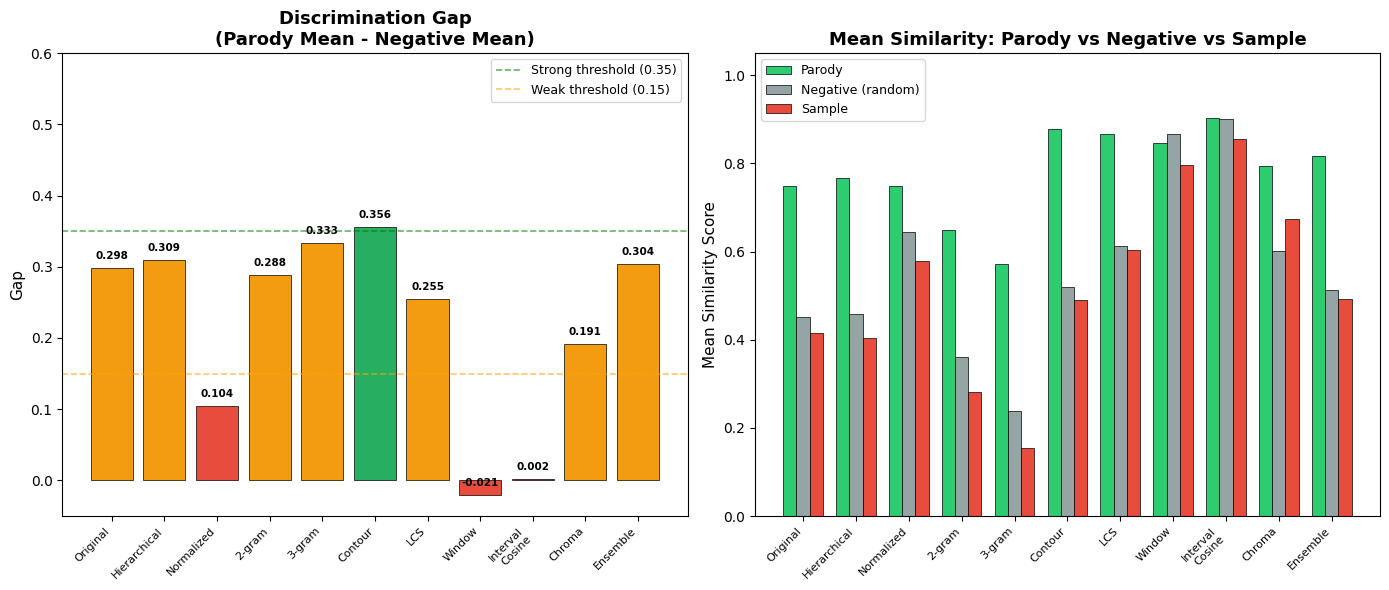

In [ ]:
parody_means = [np.mean(cat_scores["PARODY"][m]) for m in METHODS]
neg_means    = [np.mean(cat_scores["NEGATIVE"][m]) for m in METHODS]
sample_means = [np.mean(cat_scores["SAMPLE"][m]) for m in METHODS]
gaps = [p - n for p, n in zip(parody_means, neg_means)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#27ae60' if g > 0.35 else '#f39c12' if g > 0.15 else '#e74c3c' for g in gaps]
bars = axes[0].bar(METHOD_LABELS, gaps, color=colors, edgecolor='black', linewidth=0.5)
axes[0].axhline(y=0.35, color='green', lw=1.2, linestyle='--', alpha=0.6, label='Strong threshold (0.35)')
axes[0].axhline(y=0.15, color='orange', lw=1.2, linestyle='--', alpha=0.6, label='Weak threshold (0.15)')
axes[0].set_title('Discrimination Gap\n(Parody Mean - Negative Mean)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Gap', fontsize=11)
axes[0].set_ylim(-0.05, 0.60)
axes[0].tick_params(axis='x', labelsize=8, rotation=45)
axes[0].set_xticklabels(METHOD_LABELS, rotation=45, ha='right', fontsize=8)
axes[0].legend(fontsize=9)
for bar, gap in zip(bars, gaps):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{gap:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

x = np.arange(len(METHODS))
w = 0.25
axes[1].bar(x - w, parody_means, w, label='Parody', color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[1].bar(x,     neg_means,    w, label='Negative (random)', color='#95a5a6', edgecolor='black', linewidth=0.5)
axes[1].bar(x + w, sample_means, w, label='Sample', color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_title('Mean Similarity: Parody vs Negative vs Sample', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Mean Similarity Score', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(METHOD_LABELS, rotation=45, ha='right', fontsize=8)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/midi_project/results/fig1_discrimination_gap.png', dpi=150, bbox_inches='tight')
plt.show()

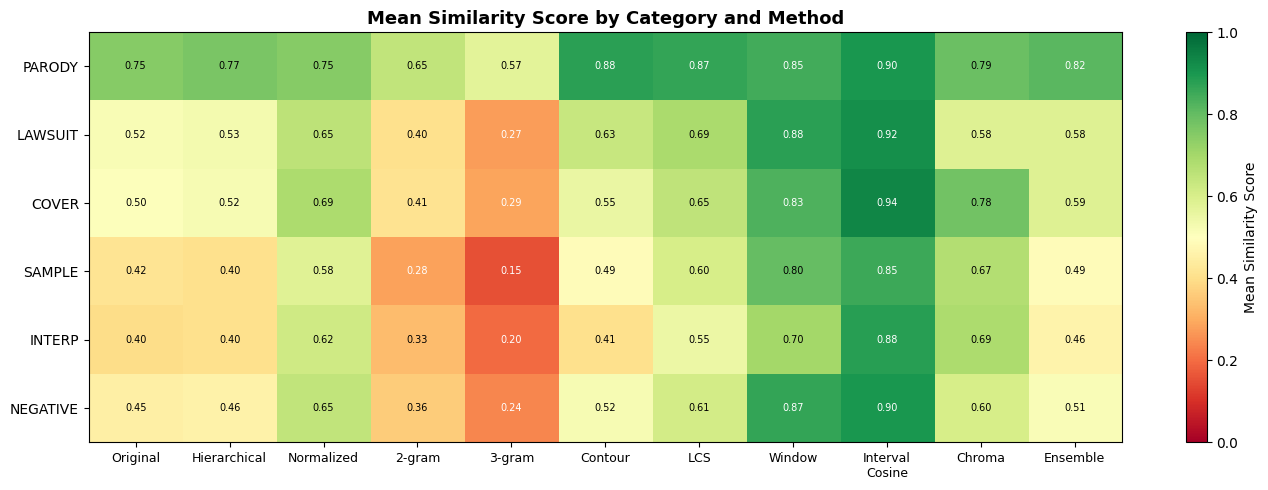

In [ ]:
heatmap_data = np.array([
    [np.mean(cat_scores[cat][m]) for m in METHODS]
    for cat in ALL_CATS
])

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Mean Similarity Score')
ax.set_xticks(range(len(METHODS)))
ax.set_xticklabels(METHOD_LABELS, fontsize=9)
ax.set_yticks(range(len(ALL_CATS)))
ax.set_yticklabels(ALL_CATS, fontsize=10)
ax.set_title('Mean Similarity Score by Category and Method', fontsize=13, fontweight='bold')
for i in range(len(ALL_CATS)):
    for j in range(len(METHODS)):
        val = heatmap_data[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if 0.3 < val < 0.8 else 'white')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/midi_project/results/fig2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

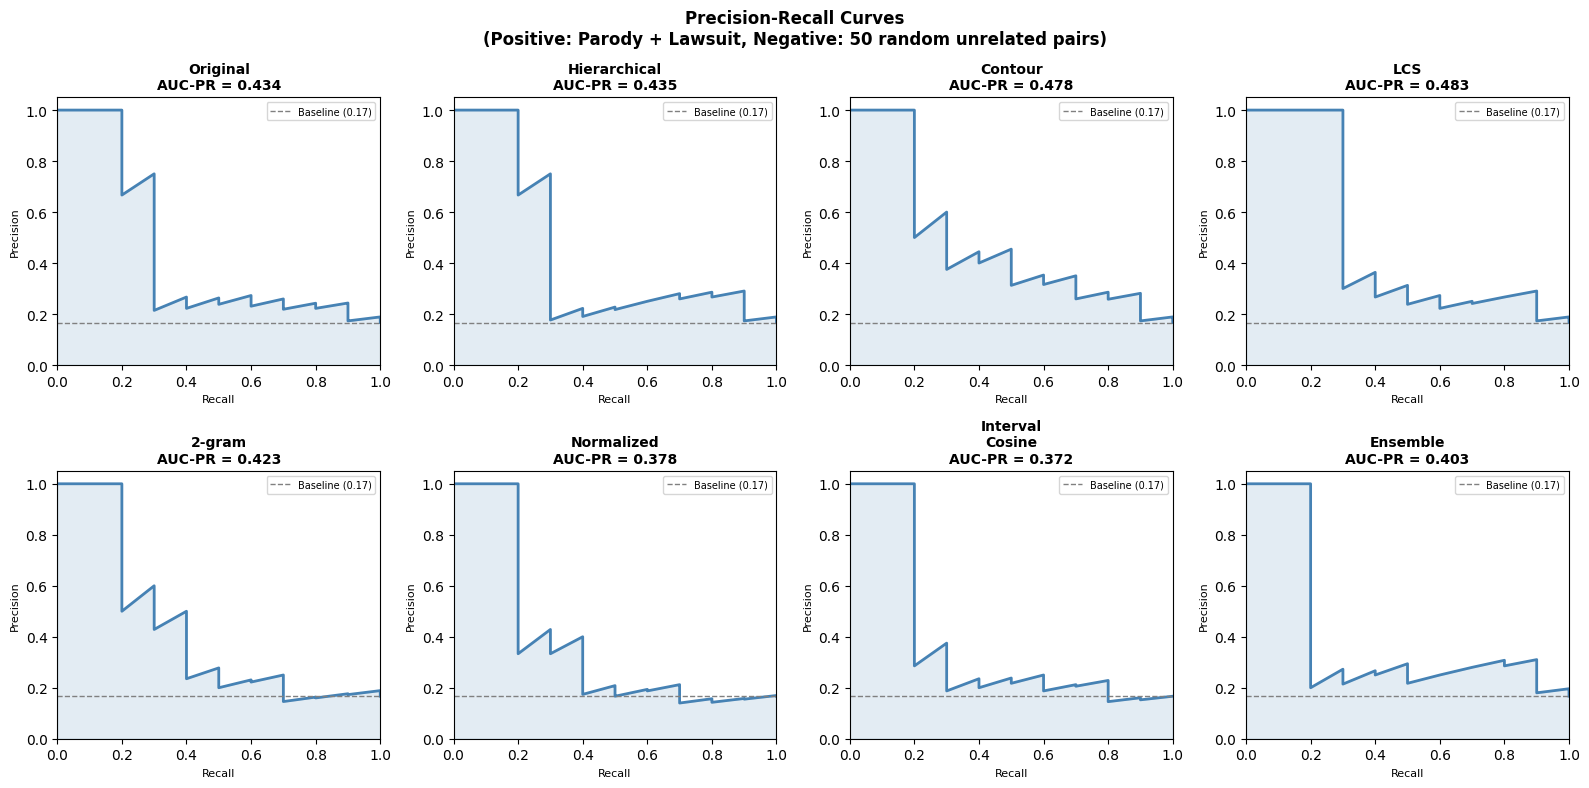

In [ ]:
pos_rows = [row for row in labeled_pairs if row[1] in ("PARODY", "LAWSUIT")]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
best_methods = ["orig", "hier", "contour", "lcs", "2gram", "norm", "interval", "ensemble"]

for ax_idx, method in enumerate(best_methods):
    mi = METHODS.index(method)
    pos_scores = [row[4 + mi] for row in pos_rows]
    neg_scores  = [row[mi] for row in neg_results]
    y_true  = [1]*len(pos_scores) + [0]*len(neg_scores)
    y_score = pos_scores + neg_scores
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    axes[ax_idx].plot(recall, precision, color='steelblue', lw=2)
    axes[ax_idx].fill_between(recall, precision, alpha=0.15, color='steelblue')
    baseline = len(pos_scores) / (len(pos_scores) + len(neg_scores))
    axes[ax_idx].axhline(baseline, color='gray', linestyle='--', lw=1, label=f'Baseline ({baseline:.2f})')
    axes[ax_idx].set_title(f'{METHOD_LABELS[mi]}\nAUC-PR = {pr_auc:.3f}', fontsize=10, fontweight='bold')
    axes[ax_idx].set_xlabel('Recall', fontsize=8)
    axes[ax_idx].set_ylabel('Precision', fontsize=8)
    axes[ax_idx].set_xlim([0, 1])
    axes[ax_idx].set_ylim([0, 1.05])
    axes[ax_idx].legend(fontsize=7)

plt.suptitle('Precision-Recall Curves\n(Positive: Parody + Lawsuit, Negative: 50 random unrelated pairs)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/midi_project/results/fig3_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()



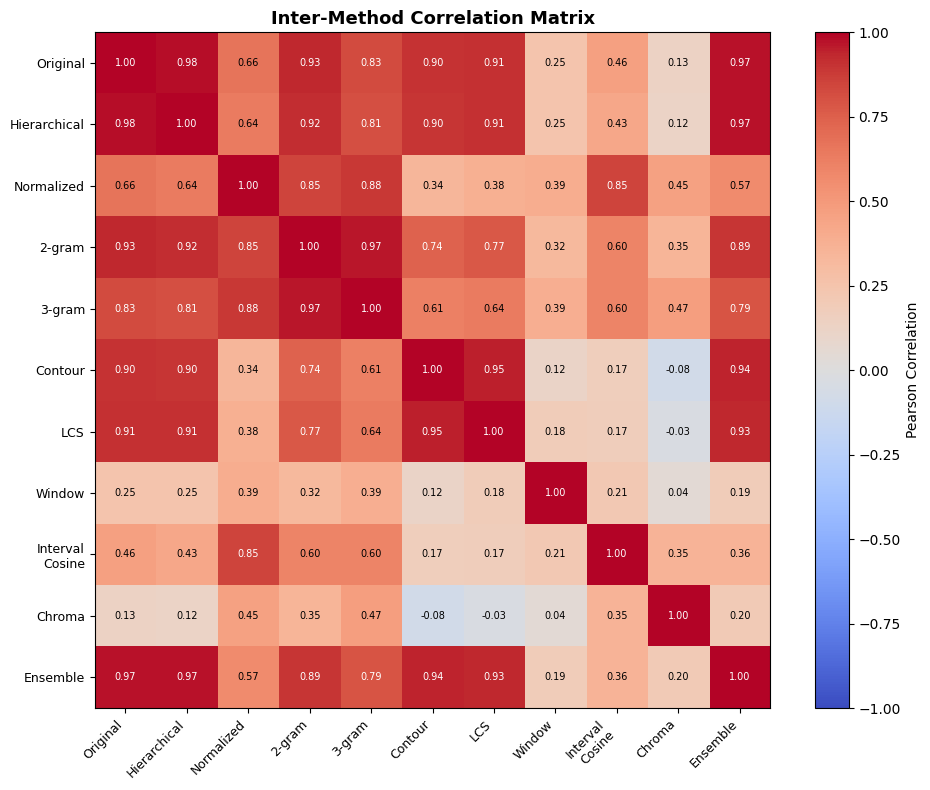

In [ ]:
all_scores = np.array([[row[4+i] for i in range(len(METHODS))] for row in labeled_pairs])
corr_matrix = np.corrcoef(all_scores.T)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_xticks(range(len(METHODS)))
ax.set_yticks(range(len(METHODS)))
ax.set_xticklabels(METHOD_LABELS, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(METHOD_LABELS, fontsize=9)
ax.set_title('Inter-Method Correlation Matrix', fontsize=13, fontweight='bold')
for i in range(len(METHODS)):
    for j in range(len(METHODS)):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(corr_matrix[i,j]) < 0.7 else 'white')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/midi_project/results/fig4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

sig_results = {}
for method in METHODS:
    ps = cat_scores["PARODY"][method]
    ss = cat_scores["SAMPLE"][method]
    ns = cat_scores["NEGATIVE"][method]
    _, p_pn = stats.mannwhitneyu(ps, ns, alternative='greater')
    _, p_sn = stats.mannwhitneyu(ss, ns, alternative='greater')
    sig_results[method] = {'parody_vs_negative': p_pn, 'sample_vs_negative': p_sn}
    sig = lambda p: "*" if p < 0.05 else "ns"
    print(f"{method:<14} Parody>Neg: p={p_pn:.4f}{sig(p_pn)}  "
          f"Sample>Neg: p={p_sn:.4f}{sig(p_sn)}")

orig           Parody>Neg: p=0.0255*  Sample>Neg: p=0.7260ns
hier           Parody>Neg: p=0.0146*  Sample>Neg: p=0.7665ns
norm           Parody>Neg: p=0.3933ns  Sample>Neg: p=0.9869ns
2gram          Parody>Neg: p=0.1125ns  Sample>Neg: p=0.9675ns
3gram          Parody>Neg: p=0.1980ns  Sample>Neg: p=0.9988ns
contour        Parody>Neg: p=0.0019*  Sample>Neg: p=0.6517ns
lcs            Parody>Neg: p=0.0107*  Sample>Neg: p=0.6201ns
window         Parody>Neg: p=0.1125ns  Sample>Neg: p=0.9443ns
interval       Parody>Neg: p=0.2287ns  Sample>Neg: p=0.9643ns
chroma         Parody>Neg: p=0.0664ns  Sample>Neg: p=0.1635ns
ensemble       Parody>Neg: p=0.0077*  Sample>Neg: p=0.6360ns


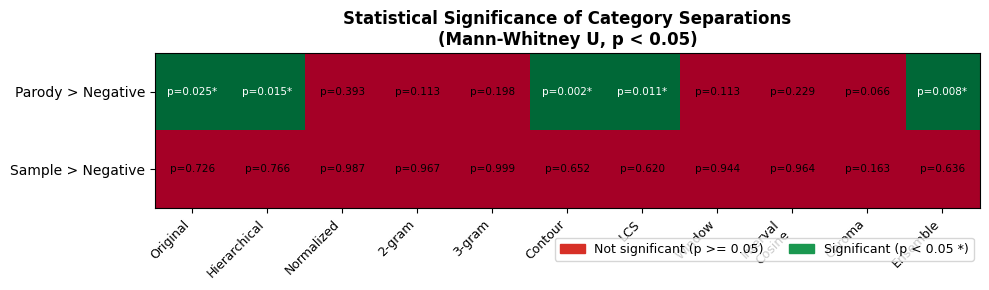

In [ ]:
comparisons = ['Parody > Negative', 'Sample > Negative']
p_matrix = np.array([
    [sig_results[m]['parody_vs_negative'],
     sig_results[m]['sample_vs_negative']]
    for m in METHODS
])
sig_display = np.where(p_matrix < 0.05, 1, 0)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(sig_display.T, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(METHODS)))
ax.set_yticks(range(len(comparisons)))
ax.set_xticklabels(METHOD_LABELS, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(comparisons, fontsize=10)
ax.set_title('Statistical Significance of Category Separations\n(Mann-Whitney U, p < 0.05)', fontsize=12, fontweight='bold')
for i in range(len(METHODS)):
    for j in range(len(comparisons)):
        p = p_matrix[i, j]
        label = f'p={p:.3f}*' if p < 0.05 else f'p={p:.3f}'
        ax.text(i, j, label, ha='center', va='center', fontsize=7.5,
                color='white' if sig_display[i, j] == 1 else 'black')
patches = [
    mpatches.Patch(color='#d73027', label='Not significant (p >= 0.05)'),
    mpatches.Patch(color='#1a9850', label='Significant (p < 0.05 *)'),
]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1, -0.15), fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_significance.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

def graph_similarity_sequential(nodes_a, edges_a, nodes_b, edges_b):
    seq_a = [e for e in edges_a if e['type'] == 'sequential']
    seq_b = [e for e in edges_b if e['type'] == 'sequential']
    return graph_similarity_bags(fingerprint_bag(seq_a), fingerprint_bag(seq_b))

def edge_fingerprint_coarse(edge):
    i = edge['interval']
    bucket = 0 if i == 0 else (1 if i > 0 else -1)
    return (edge['type'], edge['contour'], bucket)

def fingerprint_bag_coarse(edges):
    bag = {}
    for e in edges:
        k = edge_fingerprint_coarse(e)
        bag[k] = bag.get(k, 0) + 1
    return bag

def graph_similarity_coarse(nodes_a, edges_a, nodes_b, edges_b):
    ba = fingerprint_bag_coarse(edges_a)
    bb = fingerprint_bag_coarse(edges_b)
    return graph_similarity_bags(ba, bb)

def edge_fingerprint_fine(edge):
    return (edge['type'], edge['contour'], edge['interval'])

def fingerprint_bag_fine(edges):
    bag = {}
    for e in edges:
        k = edge_fingerprint_fine(e)
        bag[k] = bag.get(k, 0) + 1
    return bag

def graph_similarity_fine(nodes_a, edges_a, nodes_b, edges_b):
    ba = fingerprint_bag_fine(edges_a)
    bb = fingerprint_bag_fine(edges_b)
    return graph_similarity_bags(ba, bb)

ablation_variants = {
    "Hierarchical only":        lambda sa, sb: graph_similarity_hierarchical(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
    "Sequential only":          lambda sa, sb: graph_similarity_sequential(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
    "Original (baseline)":      lambda sa, sb: graph_similarity(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
    "Coarse buckets (sign)":    lambda sa, sb: graph_similarity_coarse(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
    "Fine buckets (semitone)":  lambda sa, sb: graph_similarity_fine(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
    "Contour only":             lambda sa, sb: graph_similarity_contour(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']),
    "Window size=4":            lambda sa, sb: graph_similarity_sliding_window(sa['nodes'], sa['edges'], sb['nodes'], sb['edges'], window_size=4),
    "Window size=6 (orig)":     lambda sa, sb: graph_similarity_sliding_window(sa['nodes'], sa['edges'], sb['nodes'], sb['edges'], window_size=6),
    "Window size=8":            lambda sa, sb: graph_similarity_sliding_window(sa['nodes'], sa['edges'], sb['nodes'], sb['edges'], window_size=8),
}

abl_scores = {name: {'PARODY': [], 'NEGATIVE': []} for name in ablation_variants}

for row in labeled_pairs:
    if row[1] != "PARODY":
        continue
    try:
        sa = load_song_by_id(row[2])
        sb = load_song_by_id(row[3])
        for name, fn in ablation_variants.items():
            abl_scores[name]['PARODY'].append(fn(sa, sb))
    except:
        pass

for ida, idb in neg_pairs:
    try:
        sa = load_song_by_id(ida)
        sb = load_song_by_id(idb)
        for name, fn in ablation_variants.items():
            abl_scores[name]['NEGATIVE'].append(fn(sa, sb))
    except:
        pass

print(f"\n{'Variant':<26} {'Parody':>8} {'Negative':>9} {'Gap (P-N)':>10}")
print("-" * 58)
abl_names, abl_parody, abl_neg, abl_gap = [], [], [], []
for name, scores in abl_scores.items():
    pm = np.mean(scores['PARODY']) if scores['PARODY'] else 0
    nm = np.mean(scores['NEGATIVE']) if scores['NEGATIVE'] else 0
    gap = pm - nm
    print(f"{name:<26} {pm:>8.4f} {nm:>9.4f} {gap:>10.4f}")
    abl_names.append(name)
    abl_parody.append(pm)
    abl_neg.append(nm)
    abl_gap.append(gap)



Variant                      Parody  Negative  Gap (P-N)
----------------------------------------------------------
Hierarchical only            0.7671    0.4582     0.3089
Sequential only              0.7325    0.4442     0.2883
Original (baseline)          0.7486    0.4508     0.2978
Coarse buckets (sign)        0.8492    0.5142     0.3350
Fine buckets (semitone)      0.6536    0.3294     0.3242
Contour only                 0.8769    0.5206     0.3563
Window size=4                0.9608    0.9764    -0.0157
Window size=6 (orig)         0.8458    0.8666    -0.0208
Window size=8                0.7508    0.6667     0.0841


In [ ]:

variant_groups = [
    ("Queen - Under Pressure",            [7461, 7481, 7488, 7502, 7560]),
    ("The Police - Every Breath You Take",[15974, 15976, 15977, 15994]),
    ("Coolio - Gangsta's Paradise",       [5776, 5777, 5778, 5781, 5782]),
    ("Led Zeppelin - Stairway to Heaven", [14430, 14442, 14458, 14460]),
]

print(f"\n{'Song Group':<42} {'N pairs':>8} {'Orig':>8} {'Hier':>8} {'Contour':>8}")
print("-" * 82)
for group_name, ids in variant_groups:
    o_s, h_s, c_s = [], [], []
    for i in range(len(ids)):
        for j in range(i+1, len(ids)):
            try:
                sa = load_song_by_id(ids[i])
                sb = load_song_by_id(ids[j])
                o_s.append(graph_similarity(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']))
                h_s.append(graph_similarity_hierarchical(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']))
                c_s.append(graph_similarity_contour(sa['nodes'], sa['edges'], sb['nodes'], sb['edges']))
            except:
                pass
    if o_s:
        print(f"{group_name:<42} {len(o_s):>8} {np.mean(o_s):>8.4f} {np.mean(h_s):>8.4f} {np.mean(c_s):>8.4f}")



Song Group                                  N pairs     Orig     Hier  Contour
----------------------------------------------------------------------------------
Queen - Under Pressure                           10   0.7258   0.7412   0.7884
The Police - Every Breath You Take                6   0.6082   0.5919   0.6353
Coolio - Gangsta's Paradise                      10   0.6497   0.6100   0.7048
Led Zeppelin - Stairway to Heaven                 6   0.5745   0.5954   0.6254
